# P1 프로젝트: 자전거 수요 예측

워싱턴 D.C. 자전거 공유 서비스의 시간당 대여량을 예측한다.

> **2011년 데이터로 학습한 모델은 2012년의 시간당 자전거 대여량을 얼마나 잘 예측할 수 있는가?**

제공된 코드를 출발점으로 머신러닝 프로젝트의 전체 흐름을 직접 수행한다. AI의 도움을 받아도 되지만, **특성 선택, 모델 선택, 결과 해석과 한계 판단은 직접 한다.**

**코드 실행**

[(구글 코랩) P1 프로젝트: 자전거 수요 예측](https://colab.research.google.com/github/codingalzi/code-workout-ml/blob/master/p1_project_bike_demand.ipynb)에서 코드를 실행할 수 있다.

**프로젝트 진행 원칙**

1. **2012년의 타깃 분포와 모델 성능은 최종 평가 전까지 확인하지 않는다.**
2. **타깃을 사실상 알려주는 정보는 입력 특성에서 제외한다.**
3. **EDA는 질문을 먼저 정한 뒤 수행한다.**
4. **AI는 도구로 활용하되 중요한 판단에는 자신의 근거를 남긴다.**

**환경설정**

In [1]:
import sys
import sklearn
from packaging.version import Version

# 파이썬 버전과 scikit-learn 버전 확인
assert sys.version_info >= (3, 10)
assert Version(sklearn.__version__) >= Version("1.6.1")

# 필요한 라이브러리 임포트
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 그래프 스타일 설정
plt.rc('font', size=12)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=12)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

## 1단계 — 문제 정의, 데이터 이해, EDA

### 문제를 데이터의 언어로 바꾼다

- **샘플**: 한 시간의 관측값
- **타깃**: 시간당 전체 자전거 대여량 `cnt`
- **특성 후보**: 시간, 계절, 요일, 날씨, 온도, 습도 등
- **문제 유형**: 수치형 타깃을 예측하는 **회귀**
- **학습·선택 데이터**: 2011년
- **최종 평가 데이터**: 2012년

과거 데이터로 학습하고 미래 데이터에서 평가하는 상황을 그대로 사용한다.

### 프로젝트 기록 ① — 분석 설계

다음을 자신의 말로 작성한다.

- **분석 목적**: 다른 특성을 이용하여 시간당 자전거 대여량을 예측하기 위한 목적
- **타깃**: 자전거 대여량
- **회귀 문제라고 판단한 이유**: 타깃이 수치형 값이므로 회귀 문제라고 판단
- **2011년과 2012년의 역할**: 2011년은 모델의 훈련과 모델 선택을 위한 훈련셋 역할, 2012년은 최종적으로 선택된 모델의 일반화 성능을 평가하기 위한 테스트셋 역할을 맡음

### 데이터를 불러와 구조를 확인한다

코드를 실행한 뒤 데이터의 행과 열이 무엇을 의미하는지 확인한다.

In [6]:
# UCI Bike Sharing 데이터 불러오기
# 처음 실행할 때 인터넷 연결이 필요하다.

!pip install ucimlrepo
from ucimlrepo import fetch_ucirepo

bike = fetch_ucirepo(id=275)

parts = []

if bike.data.features is not None:
    parts.append(bike.data.features.copy())

if bike.data.targets is not None:
    parts.append(bike.data.targets.copy())

if getattr(bike.data, "ids", None) is not None:
    parts.append(bike.data.ids.copy())

df = pd.concat(parts, axis=1)
df = df.loc[:, ~df.columns.duplicated()]

# 날짜는 이후 시간 순서 정렬에 사용한다.
df["dteday"] = pd.to_datetime(df["dteday"])

print("데이터 크기:", df.shape)
df.head()

데이터 크기: (17379, 15)


,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt,instant
0,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,16,1
1,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,40,2
2,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,32,3
3,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,13,4
4,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,1,5


필요한 열이 모두 들어왔는지 확인한다.

In [7]:
required_cols = {
    "instant", "dteday", "season", "yr", "mnth", "hr",
    "holiday", "weekday", "workingday", "weathersit",
    "temp", "atemp", "hum", "windspeed", "cnt"
}

missing_cols = sorted(required_cols - set(df.columns))

if missing_cols:
    raise ValueError(f"필요한 열이 없습니다: {missing_cols}")

print("기본 열 확인:")
print(df.columns.tolist())

기본 열 확인:
['dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'cnt', 'instant']


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   dteday      17379 non-null  datetime64[us]
 1   season      17379 non-null  int64         
 2   yr          17379 non-null  int64         
 3   mnth        17379 non-null  int64         
 4   hr          17379 non-null  int64         
 5   holiday     17379 non-null  int64         
 6   weekday     17379 non-null  int64         
 7   workingday  17379 non-null  int64         
 8   weathersit  17379 non-null  int64         
 9   temp        17379 non-null  float64       
 10  atemp       17379 non-null  float64       
 11  hum         17379 non-null  float64       
 12  windspeed   17379 non-null  float64       
 13  cnt         17379 non-null  int64         
 14  instant     17379 non-null  int64         
dtypes: datetime64[us](1), float64(4), int64(10)
memory usage: 2.0 MB


결측치가 있는지 확인한다.

In [8]:
df.isna().sum().sort_values(ascending=False).head(20)

,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0


### 데이터에서 확인할 것

출력 결과를 보고 다음을 확인한다.

- 전체 샘플 수와 변수 수
- 결측치 여부
- 숫자로 저장된 범주형 변수
- 날짜·시간 변수
- `cnt`의 의미

**관찰 기록**

> 작성:
- 17,379개의 샘플과 15개의 변수로 구성되어 있음
- 결측치 없음
- season, yr, mnth, hr, holiday, weekday, workingday, weathersit
- dteday
- 해당 날짜와 시간에 대여된 전체 자전거 대여량

### 모델링 전에 데이터 누수를 점검한다

UCI 원자료에는 `casual`, `registered`, `cnt`가 있으며 다음 관계가 성립한다.

> **`cnt = casual + registered`**

따라서 `cnt`를 예측할 때 `casual`, `registered`를 입력 특성으로 사용하면 **데이터 누수**가 발생한다.

현재 불러온 데이터에는 두 열이 포함되어 있지 않지만, 원자료를 사용할 때는 반드시 제외해야 한다.

In [9]:
# UCI 변수 설명에서 대여량 관련 변수를 확인한다.
bike.variables.loc[
    bike.variables["name"].isin(["casual", "registered", "cnt"]),
    ["name", "role", "type", "description"]
]

,name,role,type,description
14,casual,Other,Integer,count of casual users
15,registered,Other,Integer,count of registered users
16,cnt,Target,Integer,count of total rental bikes including both cas...


In [ ]:
# 현재 불러온 데이터에 세 열이 실제로 있는지 확인한다.
rental_cols = [c for c in ["casual", "registered", "cnt"] if c in df.columns]

print("현재 데이터에 포함된 대여량 관련 열:", rental_cols)

if {"casual", "registered", "cnt"}.issubset(df.columns):
    display(df[["casual", "registered", "cnt"]].head())
    print(
        "cnt = casual + registered가 모든 행에서 성립:",
        (df["cnt"] == df["casual"] + df["registered"]).all()
    )
else:
    print("casual/registered는 현재 분석 데이터에 포함되어 있지 않습니다.")
    print("다른 방식으로 원자료를 불러올 경우에는 두 열을 입력 특성에서 반드시 제외합니다.")

현재 데이터에 포함된 대여량 관련 열: ['cnt']
casual/registered는 현재 분석 데이터에 포함되어 있지 않습니다.
다른 방식으로 원자료를 불러올 경우에는 두 열을 입력 특성에서 반드시 제외합니다.


데이터 누수는 **예측 시점에 사용할 수 없거나 타깃을 사실상 알려주는 정보를 모델에 넣는 오류**다.

이번 프로젝트에서는 다음 열을 입력에서 제외한다.

- `instant`: 행 번호
- `dteday`: 시간 순서 정렬에만 사용
- `yr`: 2011년과 2012년 구분
- `cnt`: 타깃
- `casual`, `registered`: 존재할 경우 누수 발생

### 프로젝트 기록 ② — 제외할 변수

| 변수 | 제외하는 이유 |
|---|---|
| `instant` | 작성 |
| `dteday` | 작성 |
| `yr` | 작성 |
| `cnt` | 작성 |
| `casual`, `registered` | 작성 |

**누수를 확인하지 않고 성능 지표만 비교하면 왜 위험한가?**

> 작성: 데이터 누수를 확인하지 않으면 예측 시점에 사용할 수 없는 정보나 타깃을 사실상 알려주는 정보가 포함되어 잘못된 모델을 선택하게 되어 실제 예측 성능이 크게 떨어진다.   

### 2012년을 최종 평가 데이터로 보존한다

- `yr=0` → 2011년
- `yr=1` → 2012년

> **2011년: 탐색 · 학습 · 모델 선택**  
> **2012년: 최종 평가**

모델 선택이 끝날 때까지 2012년의 타깃 분포와 모델 성능은 확인하지 않는다.

In [10]:
df_2011 = df.loc[df["yr"] == 0].copy()
df_2012 = df.loc[df["yr"] == 1].copy()

print("2011년 데이터:", df_2011.shape)
print("2012년 데이터:", df_2012.shape)

print(
    "2011년 기간:",
    df_2011["dteday"].min().date(),
    "~",
    df_2011["dteday"].max().date()
)
print(
    "2012년 기간:",
    df_2012["dteday"].min().date(),
    "~",
    df_2012["dteday"].max().date()
)

2011년 데이터: (8645, 15)
2012년 데이터: (8734, 15)
2011년 기간: 2011-01-01 ~ 2011-12-31
2012년 기간: 2012-01-01 ~ 2012-12-31


### 모델을 만들기 전에 2011년 데이터를 탐색한다

EDA는 **2011년 데이터만** 사용한다. 먼저 타깃 분포를 확인한다.

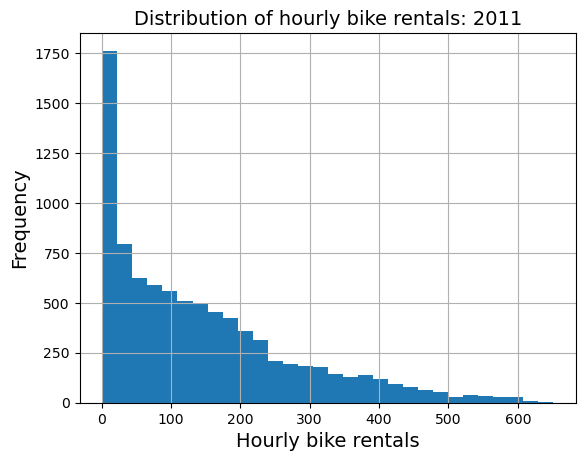

In [ ]:
df_2011["cnt"].hist(bins=30)

plt.xlabel("Hourly bike rentals")
plt.ylabel("Frequency")
plt.title("Distribution of hourly bike rentals: 2011")
plt.show()

#### 시간대에 따라 수요가 달라질까?

시간대별 평균 대여량을 확인한다.

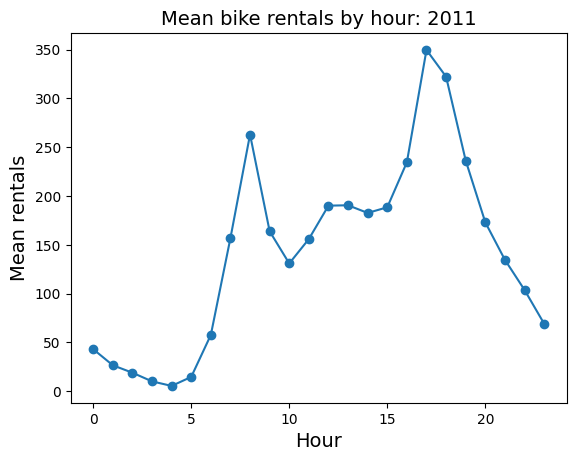

In [11]:
hourly = df_2011.groupby("hr")["cnt"].mean()

hourly.plot(marker="o")

plt.xlabel("Hour")
plt.ylabel("Mean rentals")
plt.title("Mean bike rentals by hour: 2011")
plt.show()

#### 근무일과 비근무일의 시간대별 패턴은 같을까?

`workingday`에 따라 시간대별 수요 패턴이 달라지는지 확인한다.

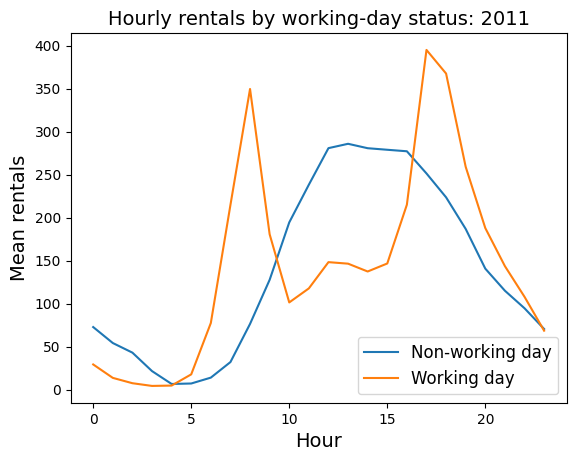

In [12]:
hour_work = (
    df_2011.groupby(["hr", "workingday"])["cnt"]
           .mean()
           .unstack()
)

hour_work.columns = ["Non-working day", "Working day"]

hour_work.plot()

plt.xlabel("Hour")
plt.ylabel("Mean rentals")
plt.title("Hourly rentals by working-day status: 2011")
plt.show()

### 나만의 EDA 질문 하나를 만든다

`season`, `mnth`, `weathersit`, `temp`, `atemp`, `hum`, `windspeed` 중 하나 이상을 사용해 질문을 만든다.

예: 날씨에 따라 수요가 다른가? 온도와 대여량은 어떤 관계가 있는가?

**나의 질문**

> 작성:

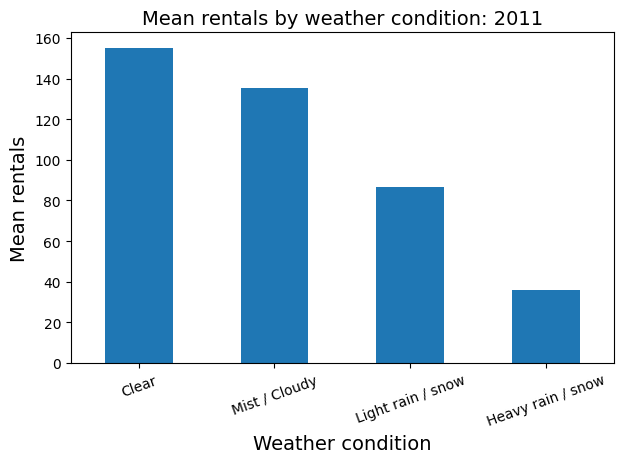

In [13]:
# TODO
# 위에서 정한 EDA 질문을 확인하는 코드를 작성한다.
weather_demand = df_2011.groupby("weathersit")["cnt"].mean()

weather_demand.index = weather_demand.index.map({
    1: "Clear",
    2: "Mist / Cloudy",
    3: "Light rain / snow",
    4: "Heavy rain / snow"
})

weather_demand.plot(kind="bar")

plt.xlabel("Weather condition")
plt.ylabel("Mean rentals")
plt.title("Mean rentals by weather condition: 2011")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### AI 체크포인트 ① — EDA

AI에게 자신의 질문과 사용할 데이터를 알려주고 분석 코드를 제안받아도 된다.

실행 전에는 **2011년 데이터만 사용하는지, 질문에 맞는 변수와 그래프인지, 해석이 결과와 일치하는지** 확인한다.

### 프로젝트 기록 ③ — EDA에서 발견한 것

세 가지를 기록한다.

- **발견 1**: 관찰 / 모델링과의 연결
- **발견 2**: 관찰 / 모델링과의 연결
- **발견 3**: 관찰 / 모델링과의 연결

> 어떤 정보가 예측에 유용할지까지 설명한다.

### 입력 특성과 타깃을 확정한다

숫자로 저장되어 있어도 모두 연속형 변수는 아니다. 예를 들어 `hr=23`은 `hr=1`의 23배라는 뜻이 아니다.

따라서 `season`, `mnth`, `hr`, `holiday`, `weekday`, `workingday`, `weathersit`은 **범주형 변수**로, 날씨 관련 연속형 변수는 수치형으로 처리한다.

In [ ]:
target = "cnt"

exclude_cols = [
    "instant", "dteday", "yr", target,
    "casual", "registered"
]

feature_cols = [
    c for c in df.columns
    if c not in exclude_cols
]

categorical_cols = [
    c for c in [
        "season", "mnth", "hr", "holiday",
        "weekday", "workingday", "weathersit"
    ]
    if c in feature_cols
]

numeric_cols = [
    c for c in feature_cols
    if c not in categorical_cols
]

print("타깃:", target)
print("사용 특성:", feature_cols)
print("범주형:", categorical_cols)
print("수치형:", numeric_cols)

타깃: cnt
사용 특성: ['season', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed']
범주형: ['season', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit']
수치형: ['temp', 'atemp', 'hum', 'windspeed']


### 1단계 마무리 체크

다음을 설명할 수 있는지 확인한다.

- 예측 대상과 문제 유형
- 2011년과 2012년의 역할
- 누수 가능 변수와 범주형 변수
- EDA 결과가 모델링과 연결되는 방식

## 2단계 — 전처리, 모델 훈련, 검증과 선택

### 2011년 안에서 학습용과 검증용 데이터를 다시 나눈다

2012년은 최종 평가용이므로 모델 선택에 사용할 수 없다.

2011년을 시간 순서대로 정렬해 앞 80%는 **학습용**, 뒤 20%는 **검증용**으로 사용한다. 무작위로 섞지 않아 실제 미래 예측 상황과 비슷하게 만든다.

In [ ]:
df_2011_ordered = (
    df_2011
    .sort_values(["dteday", "hr"])
    .reset_index(drop=True)
)

split_idx = int(len(df_2011_ordered) * 0.8)

dev_df = df_2011_ordered.iloc[:split_idx].copy()
val_df = df_2011_ordered.iloc[split_idx:].copy()

X_dev = dev_df[feature_cols]
y_dev = dev_df[target]

X_val = val_df[feature_cols]
y_val = val_df[target]

print("모델 학습용:", X_dev.shape)
print(
    "기간:",
    dev_df["dteday"].min().date(),
    "~",
    dev_df["dteday"].max().date()
)

print()

print("모델 선택용 검증:", X_val.shape)
print(
    "기간:",
    val_df["dteday"].min().date(),
    "~",
    val_df["dteday"].max().date()
)

모델 학습용: (6916, 11)
기간: 2011-01-01 ~ 2011-10-20

모델 선택용 검증: (1729, 11)
기간: 2011-10-20 ~ 2011-12-31


### 전처리 과정을 하나의 파이프라인으로 묶는다

- **수치형 변수** → 결측치 처리 + 표준화
- **범주형 변수** → 결측치 처리 + 원-핫 인코딩

현재 결측치가 없더라도 전처리 절차를 명시한다. Ridge에서는 규제가 가중치 크기에 적용되므로 수치형 특성의 스케일을 맞추는 것이 중요하다.

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer([
    ("num", numeric_pipe, numeric_cols),
    ("cat", categorical_pipe, categorical_cols)
])

전처리도 학습의 일부다. **전처리 단계는 학습 데이터에서만 `fit()`**하고, 검증·테스트 데이터에는 학습된 변환을 적용한다.

모델과 전처리를 하나의 `Pipeline`으로 묶으면 `predict()` 과정에서 이 변환이 자동으로 수행된다.

### 기준선과 여러 회귀 모델을 비교한다

이번 프로젝트에서는 다음 모델을 비교한다.

#### 기준선 모델
`DummyRegressor`는 입력 특성을 사용하지 않고 학습 데이터의 평균값처럼 단순한 값을 예측한다.

#### 선형 회귀
규제를 사용하지 않는 기본 선형 회귀 모델이다.

#### Ridge 회귀
가중치가 지나치게 커지지 않도록 규제를 적용한다. 여러 `alpha` 값을 비교해 규제 강도를 선택한다.

In [ ]:
from sklearn.base import clone
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge

def make_pipeline(estimator):
    return Pipeline([
        ("prep", clone(preprocess)),
        ("model", estimator)
    ])

models = {
    "Baseline(mean)": make_pipeline(
        DummyRegressor(strategy="mean")
    ),
    "LinearRegression": make_pipeline(
        LinearRegression()
    )
}

alpha_candidates = [0.01, 0.1, 1, 10, 100]

for alpha in alpha_candidates:
    models[f"Ridge(alpha={alpha})"] = make_pipeline(
        Ridge(alpha=alpha)
    )

print("비교할 모델:")
for name in models:
    print("-", name)

비교할 모델:
- Baseline(mean)
- LinearRegression
- Ridge(alpha=0.01)
- Ridge(alpha=0.1)
- Ridge(alpha=1)
- Ridge(alpha=10)
- Ridge(alpha=100)


### 같은 기준으로 모델을 검증한다

- **MAE**: 평균적으로 몇 대 정도 벗어나는가?
- **RMSE**: 큰 오차를 더 크게 반영한 전체 오차는 어느 정도인가?
- **R²**: 타깃의 변동을 어느 정도 설명하는가?

모델 선택의 주요 기준은 **검증 RMSE**이며, 다른 지표와 훈련·검증 성능도 함께 본다.

In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

def regression_scores(model, X, y):
    pred = model.predict(X)

    return {
        "MAE": mean_absolute_error(y, pred),
        "RMSE": np.sqrt(mean_squared_error(y, pred)),
        "R2": r2_score(y, pred)
    }

validation_rows = []

for name, model in models.items():
    model.fit(X_dev, y_dev)

    train_scores = regression_scores(model, X_dev, y_dev)
    val_scores = regression_scores(model, X_val, y_val)

    validation_rows.append({
        "Model": name,
        "Train MAE": train_scores["MAE"],
        "Validation MAE": val_scores["MAE"],
        "Train RMSE": train_scores["RMSE"],
        "Validation RMSE": val_scores["RMSE"],
        "Train R2": train_scores["R2"],
        "Validation R2": val_scores["R2"]
    })

validation_results = (
    pd.DataFrame(validation_rows)
      .set_index("Model")
      .sort_values("Validation RMSE")
)

validation_results["RMSE 차이(검증-훈련)"] = (
    validation_results["Validation RMSE"]
    - validation_results["Train RMSE"]
)

validation_results

,Train MAE,Validation MAE,Train RMSE,Validation RMSE,Train R2,Validation R2,RMSE 차이(검증-훈련)
Model,,,,,,,
Ridge(alpha=10),57.596329,52.307681,75.887856,73.340561,0.693264,0.622726,-2.547294
Ridge(alpha=1),57.501823,52.607551,75.799640,74.026152,0.693977,0.615640,-1.773487
Ridge(alpha=0.1),57.497580,52.643981,75.798244,74.116425,0.693988,0.614702,-1.681819
Ridge(alpha=0.01),57.497139,52.646812,75.798223,74.124817,0.693989,0.614614,-1.673406
LinearRegression,57.495870,52.658455,75.798199,74.131054,0.693989,0.614550,-1.667145
Ridge(alpha=100),60.427489,53.192896,79.719809,74.550983,0.661505,0.610170,-5.168826
Baseline(mean),109.147265,98.943382,137.021954,120.143076,0.000000,-0.012431,-16.878879


In [ ]:
# 검증 RMSE만 기준으로 하면 가장 낮은 모델은 무엇인지 확인한다.
suggested_model_name = validation_results["Validation RMSE"].idxmin()

print("검증 RMSE 기준 후보:", suggested_model_name)

검증 RMSE 기준 후보: Ridge(alpha=10)


### 프로젝트 기록 ④ — 모델 선택

다음을 근거와 함께 작성한다.

- 기준선보다 성능이 좋아졌는가?
- 검증 RMSE가 가장 낮은 모델은?
- 훈련 RMSE와 검증 RMSE는 어떻게 다른가?
- `alpha`에 따라 Ridge 성능은 어떻게 달라졌는가?
- 어떤 모델을 선택할 것인가? **선택 근거를 3~5문장으로 설명한다.**

### AI 체크포인트 ② — 모델 선택 결과 검토

`validation_results`와 자신의 해석을 AI에게 보여 주고 검토를 요청해도 된다.

확인할 점은 **훈련과 검증 성능을 구분했는지, 2012년 결과를 사용하지 않았는지, `alpha`의 효과나 과소·과대적합을 근거 없이 단정하지 않았는지**다.

### 최종 모델을 확정한다

코드는 검증 RMSE가 가장 낮은 모델을 후보로 제안한다. 그대로 선택하거나 다른 근거가 있다면 `chosen_model_name`을 수정한다.

**2012년 성능을 보기 전에 선택을 확정한다.**

In [ ]:
chosen_model_name = suggested_model_name

# 다른 모델을 선택할 근거가 있다면 위 값을 직접 수정한다.
# 예: chosen_model_name = "Ridge(alpha=10)"

assert chosen_model_name in models

print("최종 선택 모델:", chosen_model_name)

최종 선택 모델: Ridge(alpha=10)


### 2단계 마무리 체크

다음을 설명할 수 있는지 확인한다.

- 시간 순서대로 학습·검증 데이터를 나눈 이유
- `Pipeline`과 기준선 모델의 역할
- 훈련 성능만으로 모델을 선택하면 안 되는 이유
- Ridge의 `alpha`와 최종 모델 선택 근거

## 3단계 — 최종 평가, 오류 분석, 해석과 판단

### 선택한 모델을 2011년 전체로 다시 학습한다

모델 선택이 끝났으므로 선택한 모델을 **2011년 전체 데이터**로 다시 학습한 뒤, 처음으로 2012년 데이터에서 최종 성능을 확인한다.

In [ ]:
X_2011 = df_2011[feature_cols]
y_2011 = df_2011[target]

X_2012 = df_2012[feature_cols]
y_2012 = df_2012[target]

final_model = clone(models[chosen_model_name])
final_model.fit(X_2011, y_2011)

train_2011_scores = regression_scores(
    final_model, X_2011, y_2011
)

test_2012_scores = regression_scores(
    final_model, X_2012, y_2012
)

final_results = pd.DataFrame({
    "2011 train": train_2011_scores,
    "2012 final test": test_2012_scores
})

final_results

,2011 train,2012 final test
MAE,56.590963,110.327700
RMSE,75.168869,158.642954
R2,0.684334,0.423275


### 프로젝트 기록 ⑤ — 최종 성능 해석

지표를 숫자 그대로 옮기지 말고 의미를 설명한다.

- **MAE 해석**:
- **RMSE 해석**:
- **R² 해석**:
- **2011년 전체 훈련 성능과 2012년 최종 테스트 성능의 차이**:

### 전체 점수 하나만 보고 끝내지 않는다

전체 지표가 좋아도 특정 상황에서는 오차가 클 수 있다. 실제값과 예측값의 관계를 확인한다.

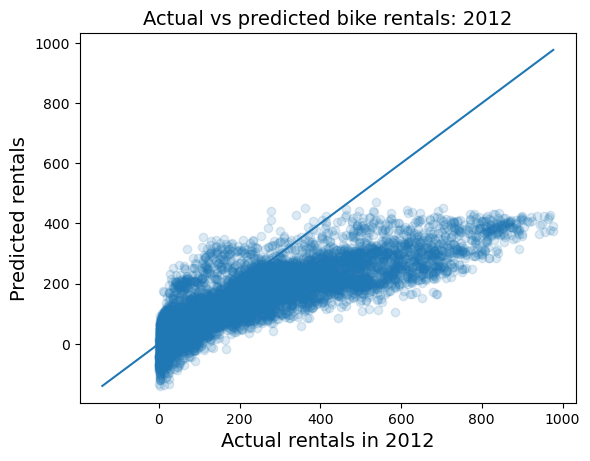

In [ ]:
pred_2012 = final_model.predict(X_2012)

plt.scatter(y_2012, pred_2012, alpha=0.15)

low = min(y_2012.min(), pred_2012.min())
high = max(y_2012.max(), pred_2012.max())

plt.plot([low, high], [low, high])

plt.xlabel("Actual rentals in 2012")
plt.ylabel("Predicted rentals")
plt.title("Actual vs predicted bike rentals: 2012")
plt.show()

### 시간대별 오류를 확인한다

전체 평균뿐 아니라 **시간대별 평균 절대오차**를 확인해 어느 시간대에서 예측이 어려운지 살펴본다.

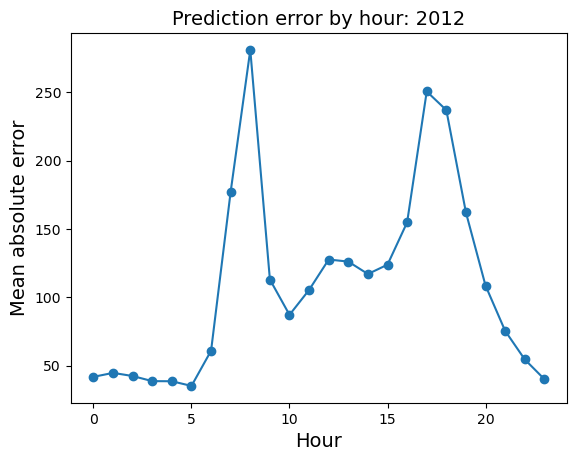

In [ ]:
errors_2012 = pd.DataFrame({
    "hr": X_2012["hr"].to_numpy(),
    "workingday": X_2012["workingday"].to_numpy(),
    "weathersit": X_2012["weathersit"].to_numpy(),
    "actual": y_2012.to_numpy(),
    "predicted": pred_2012
})

errors_2012["error"] = (
    errors_2012["actual"]
    - errors_2012["predicted"]
)

errors_2012["abs_error"] = (
    errors_2012["error"].abs()
)

hour_error = (
    errors_2012
    .groupby("hr")["abs_error"]
    .mean()
)

hour_error.plot(marker="o")

plt.xlabel("Hour")
plt.ylabel("Mean absolute error")
plt.title("Prediction error by hour: 2012")
plt.show()

### 조건을 하나 더 선택해 오류를 분석한다

`workingday` 또는 `weathersit`을 선택해 조건별 오류를 비교한다.

In [ ]:
analysis_col = "workingday"  # TODO: 필요하면 "weathersit"으로 바꾼다.

condition_error = (
    errors_2012
    .groupby(analysis_col)["abs_error"]
    .agg(["mean", "median", "count"])
)

condition_error

,mean,median,count
workingday,,,
0,116.775032,75.816029,2780
1,107.317357,63.093481,5954


### 프로젝트 기록 ⑥ — 오류 분석

다음을 기록한다.

- 오차가 큰 시간대와 그때의 수요 수준
- 선택한 조건에서 오차가 큰 집단
- 전체 RMSE만으로는 놓칠 수 있는 점
- 실제 운영에서 주의할 상황

### 2012년에서 성능이 달라진 이유를 살펴본다

최종 평가가 끝났으므로 2011년과 2012년을 비교한다. 두 해의 수요 수준이나 데이터 분포가 다르면 2012년 예측 성능도 달라질 수 있다.

In [ ]:
df.groupby("yr")["cnt"].agg(
    ["mean", "median", "std", "min", "max"]
)

,mean,median,std,min,max
yr,,,,,
0,143.794448,109.0,133.797854,1,651
1,234.666361,191.0,208.910941,1,977


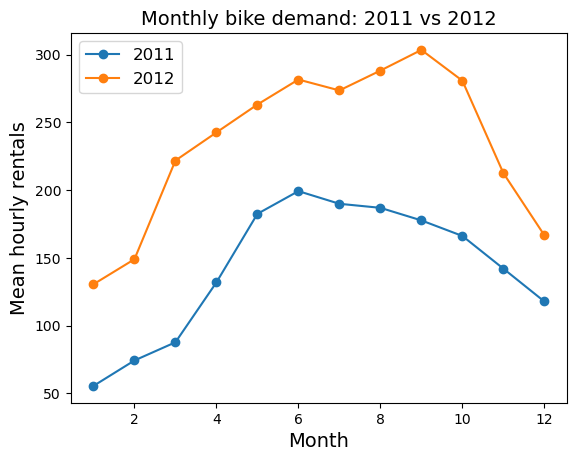

In [ ]:
monthly = (
    df.groupby(["yr", "mnth"])["cnt"]
      .mean()
      .unstack(0)
)

monthly.columns = ["2011", "2012"]

monthly.plot(marker="o")

plt.xlabel("Month")
plt.ylabel("Mean hourly rentals")
plt.title("Monthly bike demand: 2011 vs 2012")
plt.show()

2011년과 2012년의 차이를 보며 다음 가능성을 검토한다.

- 모델이 관계를 충분히 표현하지 못했는가?
- 2011년에 지나치게 맞춰졌는가?
- 2012년의 데이터 분포나 관계가 달라졌는가?
- 중요한 정보가 빠져 있는가?

> **낮은 테스트 성능과 그 원인에 대한 설명은 구분해야 한다.**

### 예측 관계와 인과관계를 구분한다

“온도 정보가 예측에 유용했다”와 “온도가 높아지면 대여량이 증가한다”는 다른 주장이다.

이번 프로젝트의 관찰 데이터와 예측 모델만으로는 **인과관계를 단정하기 어렵다.**

### AI 체크포인트 ③ — 결과 해석 검토

최종 결과와 오류 분석을 AI에게 보여 주고 결론 초안을 검토받아도 된다.

다음은 직접 확인한다.

- 2013년 이후에도 같은 성능을 보장한다고 하지 않는가?
- 예측 관계를 인과관계로 바꾸지 않았는가?
- 테스트 한 번으로 일반화를 증명했다고 하지 않는가?
- 조건별 오류와 분석의 한계를 반영했는가?

**수정하거나 받아들이지 않은 AI의 제안과 그 이유**

> 작성:

### 최종 결론을 작성한다

다음 내용을 포함한다.

- **분석 질문에 대한 답**
- **선택한 모델과 선택 근거**
- **핵심 성능과 의미**
- **오차가 큰 상황**
- **실제 활용 가능성**
- **분석의 한계 두 가지 이상**
- **다음 분석에서 추가할 정보 또는 방법**

### 프로젝트 최종 제출 전 확인

- [ ] 타깃, 특성, 제외 변수와 데이터 분할을 설명했다.
- [ ] EDA 질문을 만들고 결과를 해석했다.
- [ ] 전처리와 모델 비교·선택 근거를 설명했다.
- [ ] 모델 선택 후 2012년에서 최종 평가했다.
- [ ] MAE, RMSE, R²와 조건별 오류를 해석했다.
- [ ] 예측과 인과를 구분하고 한계를 적었다.
- [ ] AI의 제안을 검토한 근거를 남겼다.

### 평가 기준

| 영역 | 배점 | 확인할 내용 |
|---|---:|---|
| 문제와 데이터 이해 | 4 | 타깃·특성·누수 및 시간 순서를 고려한 분석 설계를 적절히 설명했는가? |
| 분석 방법 | 4 | EDA·전처리·모델 비교·검증 절차가 타당한가? |
| 결과 해석 | 5 | 지표와 그래프를 현실의 언어로 정확히 해석했는가? |
| 판단 | 4 | 모델 선택과 최종 결론에 자신의 근거가 있는가? |
| 검증과 한계 | 3 | AI 결과 검토, 오류 분석, 일반화와 한계를 적절히 다루었는가? |
| **합계** | **20** | |